# DSB reproduction


今回は3つのモデル　ConvNextV2 Atto, 

In [5]:
# Cell 1: 学習曲線データの読み込み
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

RUN_ROOT = Path("/home/nakano/server/checkpoints_dense/vision_plain/cifar10")

def natural_ckpt_key(p: Path):
    m = re.search(r"checkpoint-(\d+)", p.name)
    return int(m.group(1)) if m else -1

def load_log_history(net_name: str):
    run_dir = RUN_ROOT / net_name
    ckpt_dirs = sorted(
        [d for d in run_dir.iterdir() if d.is_dir() and d.name.startswith("checkpoint-")],
        key=natural_ckpt_key,
    )
    latest = ckpt_dirs[-1]
    state = json.load(open(latest / "trainer_state.json"))
    entries = [e for e in state["log_history"] if "loss" in e]
    steps = np.array([e["step"] for e in entries])
    epochs = np.array([e["epoch"] for e in entries])
    losses = np.array([e["loss"] for e in entries])
    grad_norms = np.array([e.get("grad_norm", np.nan) for e in entries])
    lrs = np.array([e.get("learning_rate", np.nan) for e in entries])
    return {"steps": steps, "epochs": epochs, "loss": losses, "grad_norm": grad_norms, "lr": lrs}

logs = {net: load_log_history(net) for net in ["convnext-atto", "regnet-400mf", "swin-atto"]}
for net, d in logs.items():
    print(f"{net}: {len(d['steps'])} log points, final loss={d['loss'][-1]:.4f}")

convnext-atto: 620 log points, final loss=0.0158
regnet-400mf: 620 log points, final loss=0.8252
swin-atto: 620 log points, final loss=0.2746


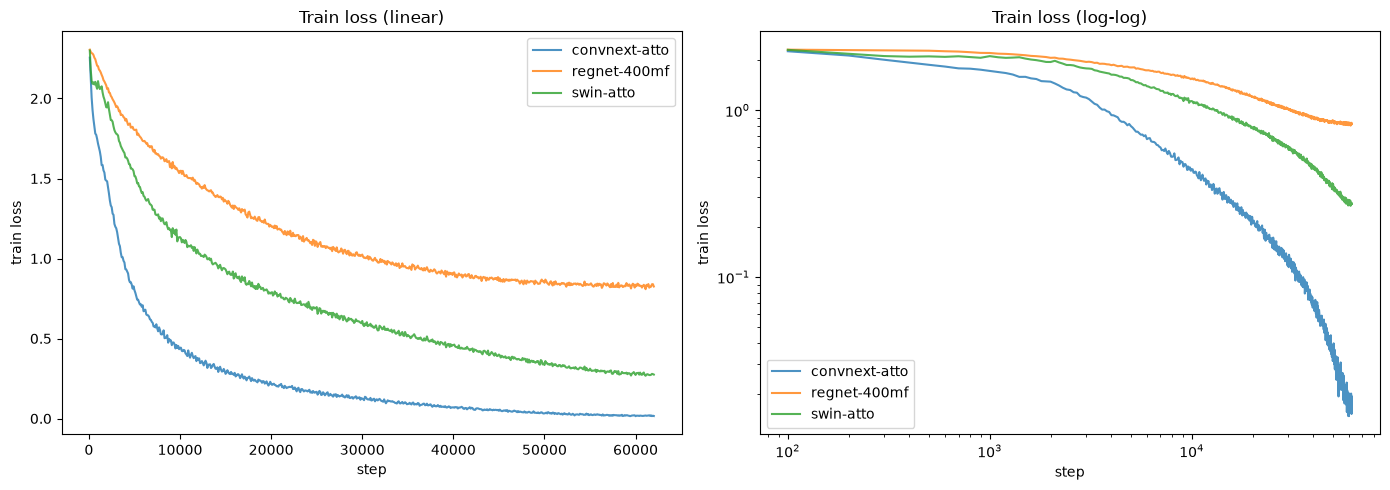

In [6]:
# Cell 2: loss推移の描画(線形スケール + logスケール)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {"convnext-atto": "tab:blue", "regnet-400mf": "tab:orange", "swin-atto": "tab:green"}

for net, d in logs.items():
    axes[0].plot(d["steps"], d["loss"], label=net, alpha=0.8, color=colors[net])
    axes[1].plot(d["steps"], d["loss"], label=net, alpha=0.8, color=colors[net])

axes[0].set_xlabel("step")
axes[0].set_ylabel("train loss")
axes[0].set_title("Train loss (linear)")
axes[0].legend()

axes[1].set_xlabel("step")
axes[1].set_ylabel("train loss")
axes[1].set_yscale("log")
axes[1].set_xscale("log")
axes[1].set_title("Train loss (log-log)")
axes[1].legend()

plt.tight_layout()
plt.show()

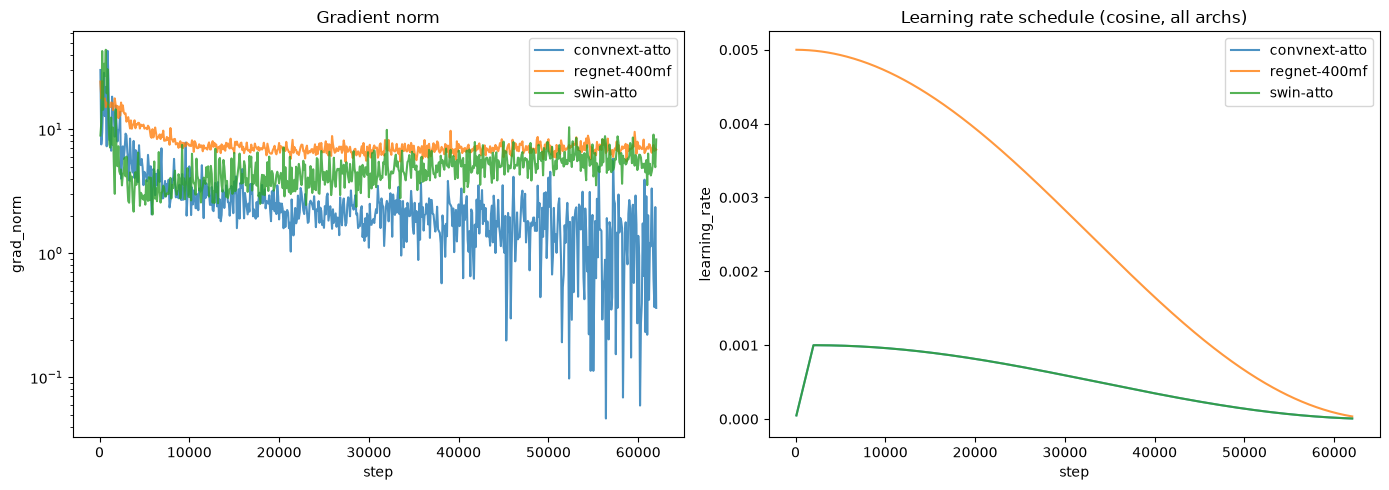

In [7]:
# Cell 3: grad_norm と learning_rate の推移
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for net, d in logs.items():
    axes[0].plot(d["steps"], d["grad_norm"], label=net, alpha=0.8, color=colors[net])
    axes[1].plot(d["steps"], d["lr"], label=net, alpha=0.8, color=colors[net])

axes[0].set_xlabel("step")
axes[0].set_ylabel("grad_norm")
axes[0].set_yscale("log")
axes[0].set_title("Gradient norm")
axes[0].legend()

axes[1].set_xlabel("step")
axes[1].set_ylabel("learning_rate")
axes[1].set_title("Learning rate schedule (cosine, all archs)")
axes[1].legend()

plt.tight_layout()
plt.show()

convnext-atto: 112 points, final test_acc=0.9293
regnet-400mf: 112 points, final test_acc=0.7521
swin-atto: 112 points, final test_acc=0.8927


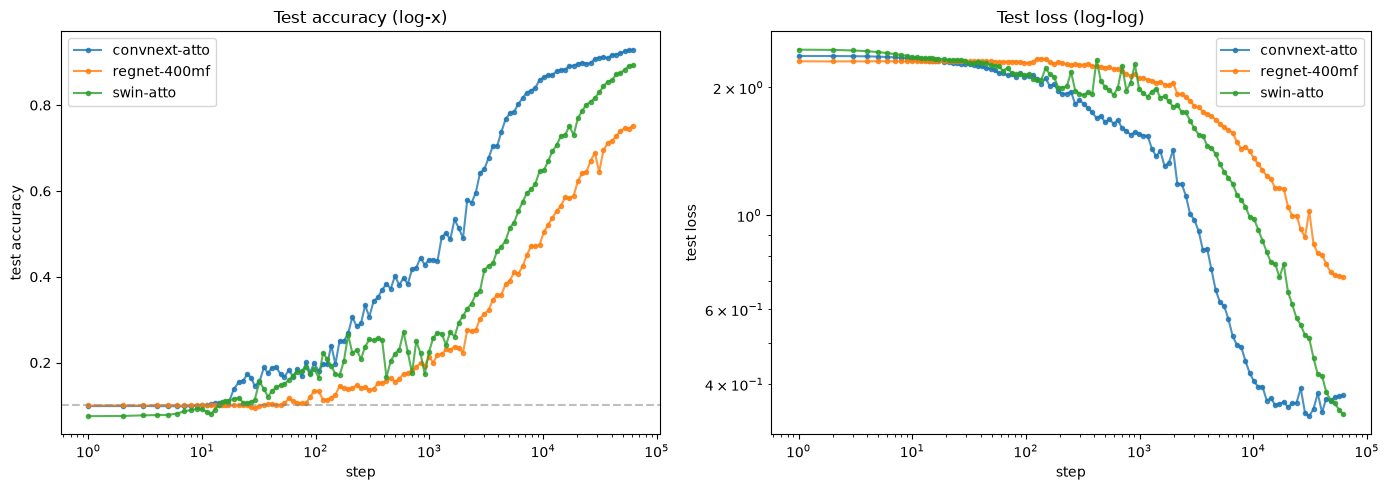

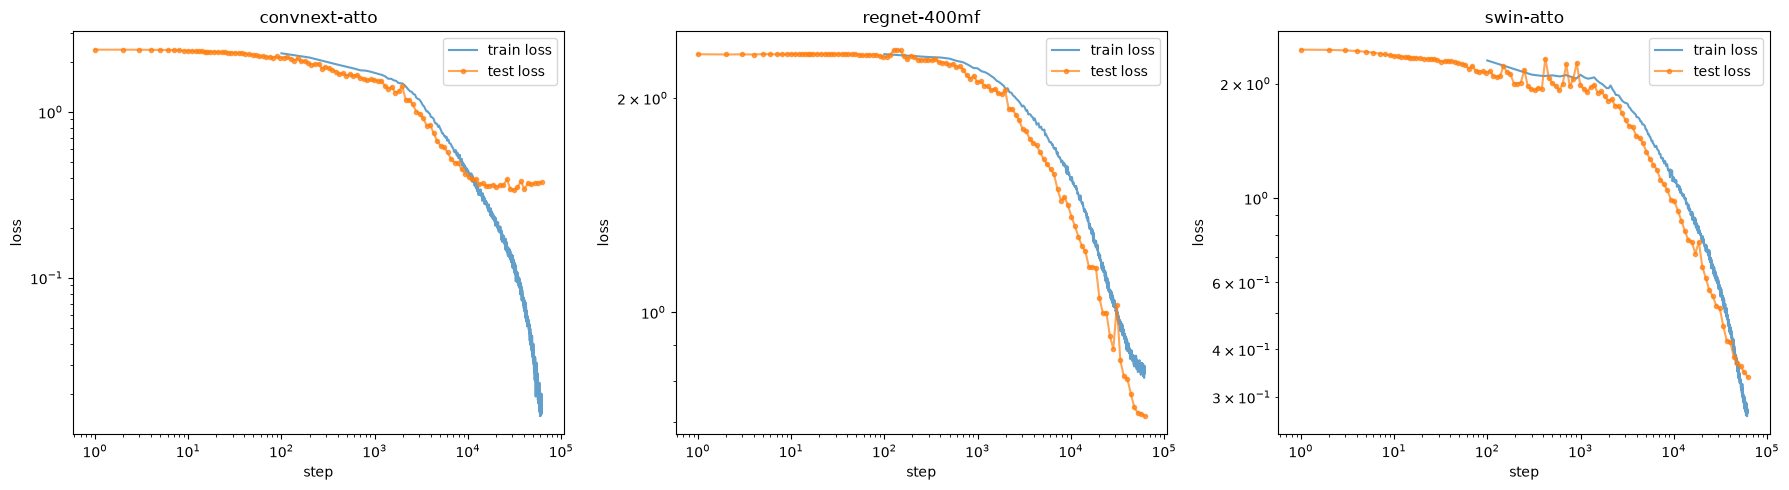

In [8]:
# Cell 4: test accuracy / test loss の読み込み
import pandas as pd

RUN_ROOT = Path("/home/nakano/server/checkpoints_dense/vision_plain/cifar10")

eval_dfs = {
    net: pd.read_csv(RUN_ROOT / net / "eval_curve.csv").sort_values("step")
    for net in ["convnext-atto", "regnet-400mf", "swin-atto"]
}

for net, df in eval_dfs.items():
    print(f"{net}: {len(df)} points, final test_acc={df['test_acc'].iloc[-1]:.4f}")
    
# Cell 5: test accuracy / test loss の推移(線形 + log-x)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for net, df in eval_dfs.items():
    axes[0].plot(df["step"], df["test_acc"], label=net, alpha=0.8, color=colors[net], marker='.')
    axes[1].plot(df["step"], df["test_loss"], label=net, alpha=0.8, color=colors[net], marker='.')

axes[0].set_xlabel("step")
axes[0].set_ylabel("test accuracy")
axes[0].set_xscale("log")
axes[0].set_title("Test accuracy (log-x)")
axes[0].legend()
axes[0].axhline(0.1, color='gray', linestyle='--', alpha=0.5, label='random baseline')

axes[1].set_xlabel("step")
axes[1].set_ylabel("test loss")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Test loss (log-log)")
axes[1].legend()

plt.tight_layout()
plt.show()

# Cell 6: train loss vs test loss(汎化ギャップ)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, net in enumerate(["convnext-atto", "regnet-400mf", "swin-atto"]):
    train_d = logs[net]
    test_d = eval_dfs[net]
    axes[i].plot(train_d["steps"], train_d["loss"], label="train loss", alpha=0.7)
    axes[i].plot(test_d["step"], test_d["test_loss"], label="test loss", alpha=0.7, marker='.')
    axes[i].set_xlabel("step")
    axes[i].set_ylabel("loss")
    axes[i].set_xscale("log")
    axes[i].set_yscale("log")
    axes[i].set_title(net)
    axes[i].legend()

plt.tight_layout()
plt.show()

DSBの結果

In [9]:
# Cell 7: moment_data評価結果の読み込み
RUN_ROOT = Path("/home/nakano/server/checkpoints_dense/vision_plain/cifar10")
NETS = ["convnext-atto", "regnet-400mf", "swin-atto"]

moment_dfs = {}
for net in NETS:
    df_graft = pd.read_csv(RUN_ROOT / net / "moment_eval_graft.csv")
    df_del = pd.read_csv(RUN_ROOT / net / "moment_eval_del.csv")
    moment_dfs[net] = pd.concat([df_graft, df_del], ignore_index=True).sort_values(["condition", "step"])

for net, df in moment_dfs.items():
    print(f"{net}: {df['condition'].nunique()} conditions, {len(df)} rows")

convnext-atto: 7 conditions, 784 rows
regnet-400mf: 7 conditions, 784 rows
swin-atto: 7 conditions, 784 rows


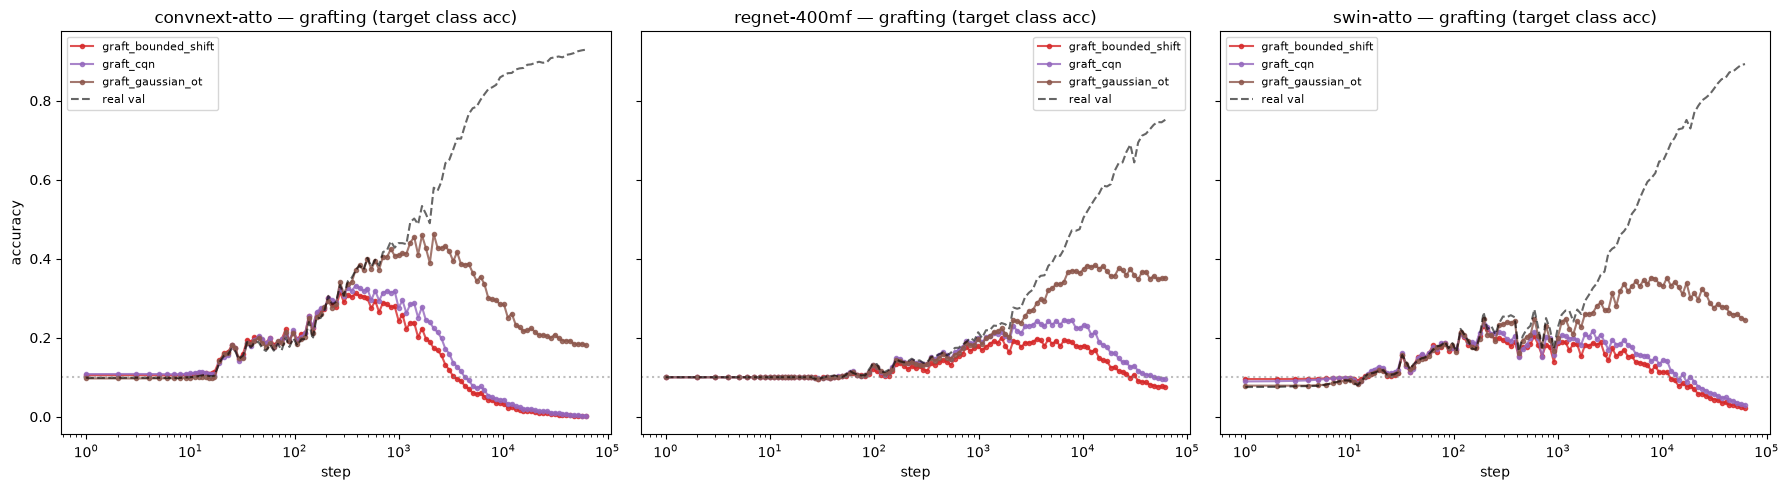

In [10]:
# Cell 8: grafting accuracy推移(論文Fig.3相当) — モデルごとにパネルを分ける
graft_conditions = ["graft_bounded_shift", "graft_cqn", "graft_gaussian_ot"]
graft_colors = {"graft_bounded_shift": "tab:red", "graft_cqn": "tab:purple", "graft_gaussian_ot": "tab:brown"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, net in enumerate(NETS):
    df = moment_dfs[net]
    for cond in graft_conditions:
        sub = df[df["condition"] == cond].sort_values("step")
        axes[i].plot(sub["step"], sub["acc"], label=cond, color=graft_colors[cond], marker='.', alpha=0.8)
    # 通常のtest accuracyも重ねる(参照用)
    axes[i].plot(eval_dfs[net]["step"], eval_dfs[net]["test_acc"], label="real val", color="black", linestyle="--", alpha=0.6)
    axes[i].axhline(0.1, color='gray', linestyle=':', alpha=0.5)
    axes[i].set_xscale("log")
    axes[i].set_xlabel("step")
    axes[i].set_title(f"{net} — grafting (target class acc)")
    axes[i].legend(fontsize=8)

axes[0].set_ylabel("accuracy")
plt.tight_layout()
plt.show()

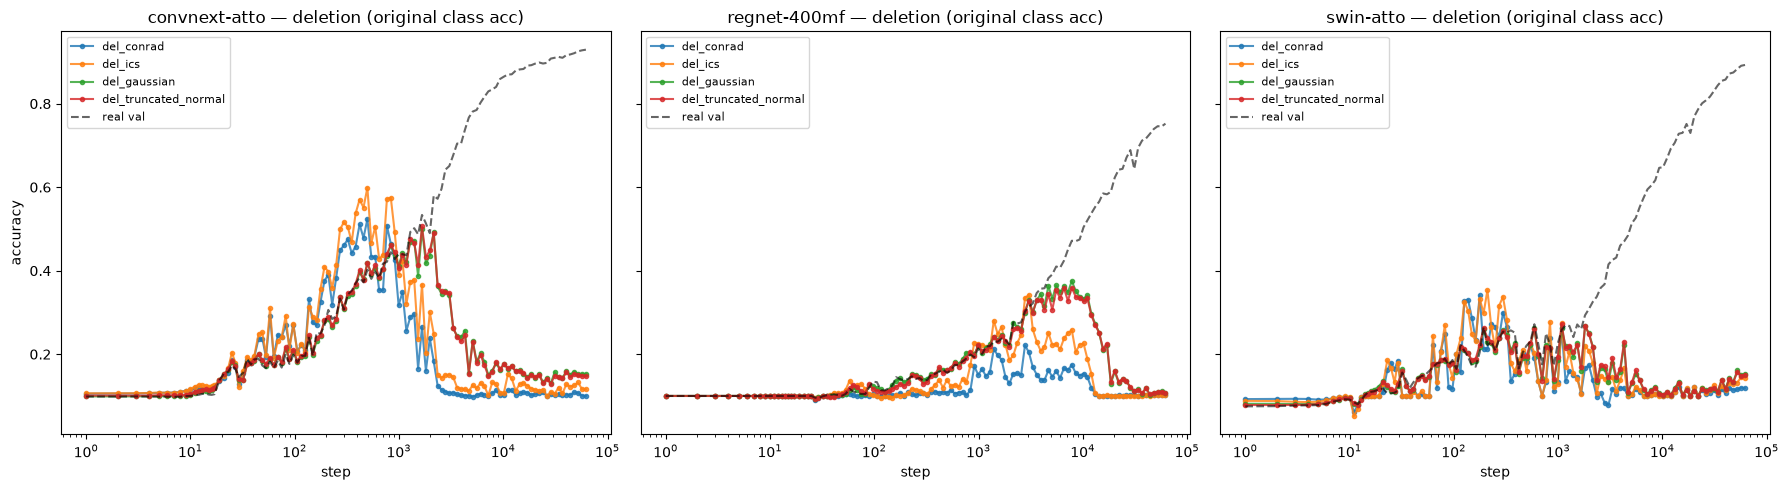

In [11]:
# Cell 9: deletion accuracy推移(論文Fig.5相当)
del_conditions = ["del_conrad", "del_ics", "del_gaussian", "del_truncated_normal"]
del_colors = {"del_conrad": "tab:blue", "del_ics": "tab:orange", "del_gaussian": "tab:green", "del_truncated_normal": "tab:red"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, net in enumerate(NETS):
    df = moment_dfs[net]
    for cond in del_conditions:
        sub = df[df["condition"] == cond].sort_values("step")
        axes[i].plot(sub["step"], sub["acc"], label=cond, color=del_colors[cond], marker='.', alpha=0.8)
    axes[i].plot(eval_dfs[net]["step"], eval_dfs[net]["test_acc"], label="real val", color="black", linestyle="--", alpha=0.6)
    axes[i].set_xscale("log")
    axes[i].set_xlabel("step")
    axes[i].set_title(f"{net} — deletion (original class acc)")
    axes[i].legend(fontsize=8)

axes[0].set_ylabel("accuracy")
plt.tight_layout()
plt.show()

# LLCのキャリブレーション

## 学習の最終ステップでみた結果,通常のトレーニングデータに対する

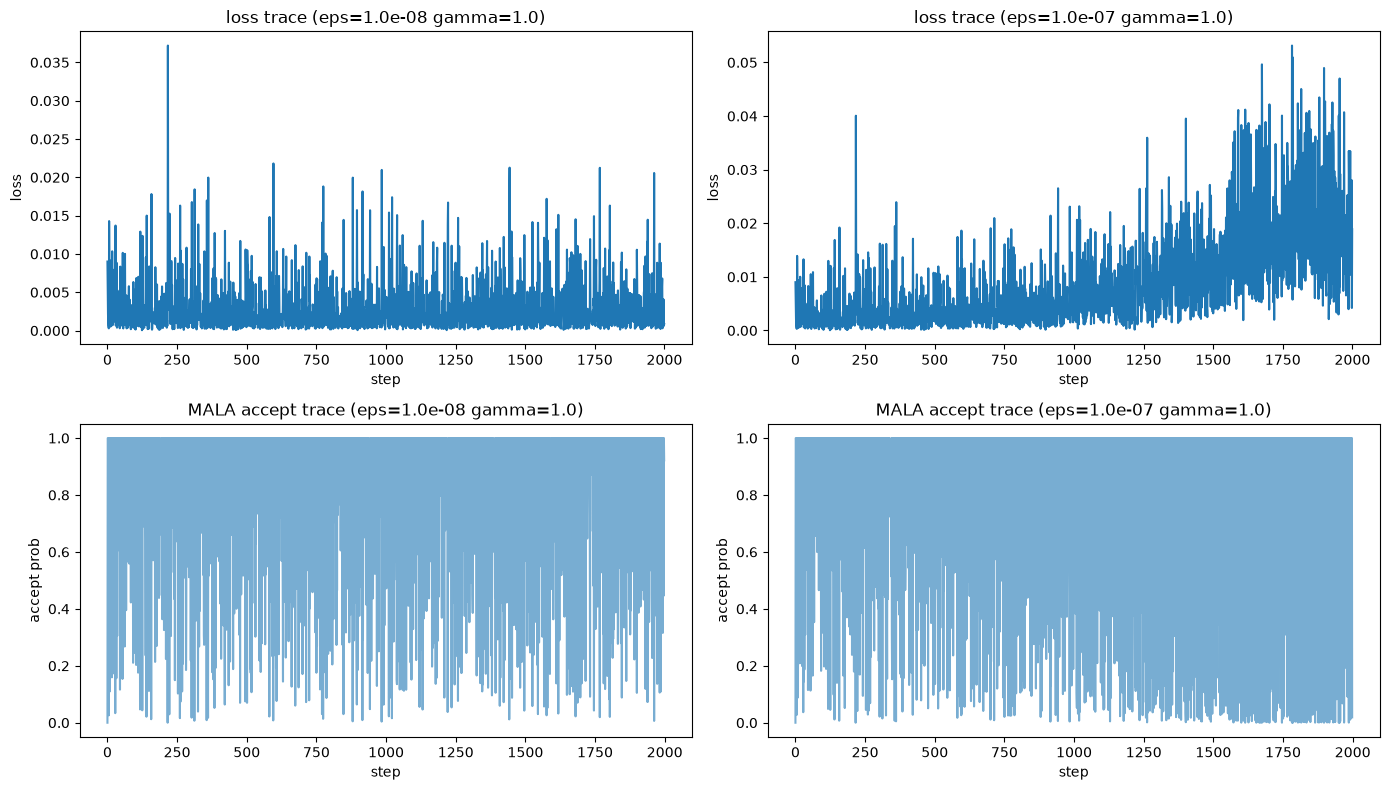

In [4]:
import json
import matplotlib.pyplot as plt
import numpy as np

d2 = json.load(open('/home/nakano/server/calibration_results_vision_test_gpu2/calib_convnext-atto.json'))
d3 = json.load(open('/home/nakano/server/calibration_results_vision_test_gpu3/calib_convnext-atto.json'))

r_1e8 = d2['records'][0]
r_1e7 = d3['records'][0]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, r in enumerate([r_1e8, r_1e7]):
    loss_trace = np.array(r['loss_trace'])
    accept_trace = np.array(r['mala_accept_trace'])
    label = f"eps={r['epsilon']:.1e} gamma={r['gamma']}"

    axes[0, i].plot(loss_trace)
    axes[0, i].set_title(f"loss trace ({label})")
    axes[0, i].set_xlabel("step")
    axes[0, i].set_ylabel("loss")

    axes[1, i].plot(accept_trace, alpha=0.6)
    axes[1, i].set_title(f"MALA accept trace ({label})")
    axes[1, i].set_xlabel("step")
    axes[1, i].set_ylabel("accept prob")
    axes[1, i].set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

In [5]:
import numpy as np

def compute_llc_with_burnin(loss_trace, nbeta, burnin_frac=0.9):
    """
    loss_trace: 全ステップのloss配列
    nbeta: n/log(n)
    burnin_frac: 捨てる割合(0.9 = 先頭90%を捨てて末尾10%を使う)
    """
    trace = np.array(loss_trace)
    n_burnin = int(len(trace) * burnin_frac)
    post_burnin = trace[n_burnin:]

    init_loss = trace[0]  # サンプリング開始直後のloss(基準点)
    avg_loss = post_burnin.mean()
    llc = nbeta * (avg_loss - init_loss)

    return {
        "llc": llc,
        "avg_loss_post_burnin": avg_loss,
        "init_loss": init_loss,
        "n_burnin": n_burnin,
        "n_post_burnin": len(post_burnin),
    }


for r, label in [(r_1e8, "eps=1e-8"), (r_1e7, "eps=1e-7")]:
    res = compute_llc_with_burnin(r["loss_trace"], r["nbeta"], burnin_frac=0.9)
    print(f"{label}: llc={res['llc']:.4f}  avg_loss_post_burnin={res['avg_loss_post_burnin']:.5f}  "
          f"init_loss={res['init_loss']:.5f}  n_post_burnin={res['n_post_burnin']}")

eps=1e-8: llc=-1.6154  avg_loss_post_burnin=0.00299  init_loss=0.00901  n_post_burnin=200
eps=1e-7: llc=2.9719  avg_loss_post_burnin=0.02007  init_loss=0.00901  n_post_burnin=200


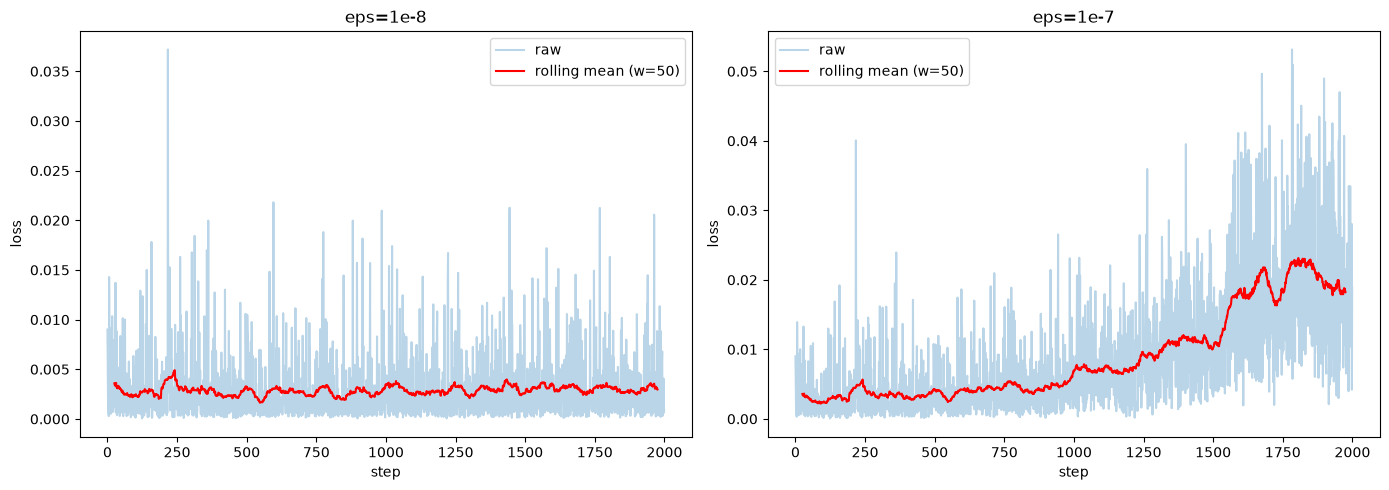

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def rolling_mean(x, window=50):
    x = np.array(x)
    return np.convolve(x, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (r, label) in enumerate([(r_1e8, "eps=1e-8"), (r_1e7, "eps=1e-7")]):
    trace = np.array(r["loss_trace"])
    rm = rolling_mean(trace, window=50)
    axes[i].plot(trace, alpha=0.3, label="raw")
    axes[i].plot(np.arange(len(rm)) + 25, rm, color="red", label="rolling mean (w=50)")
    axes[i].set_title(f"{label}")
    axes[i].set_xlabel("step")
    axes[i].set_ylabel("loss")
    axes[i].legend()

plt.tight_layout()
plt.show()

gammas: [0.1, 0.5, 1.0, 3.0, 5.0]
epsilons: [1e-11, 1e-10, 1e-09, 1e-08, 3e-08]


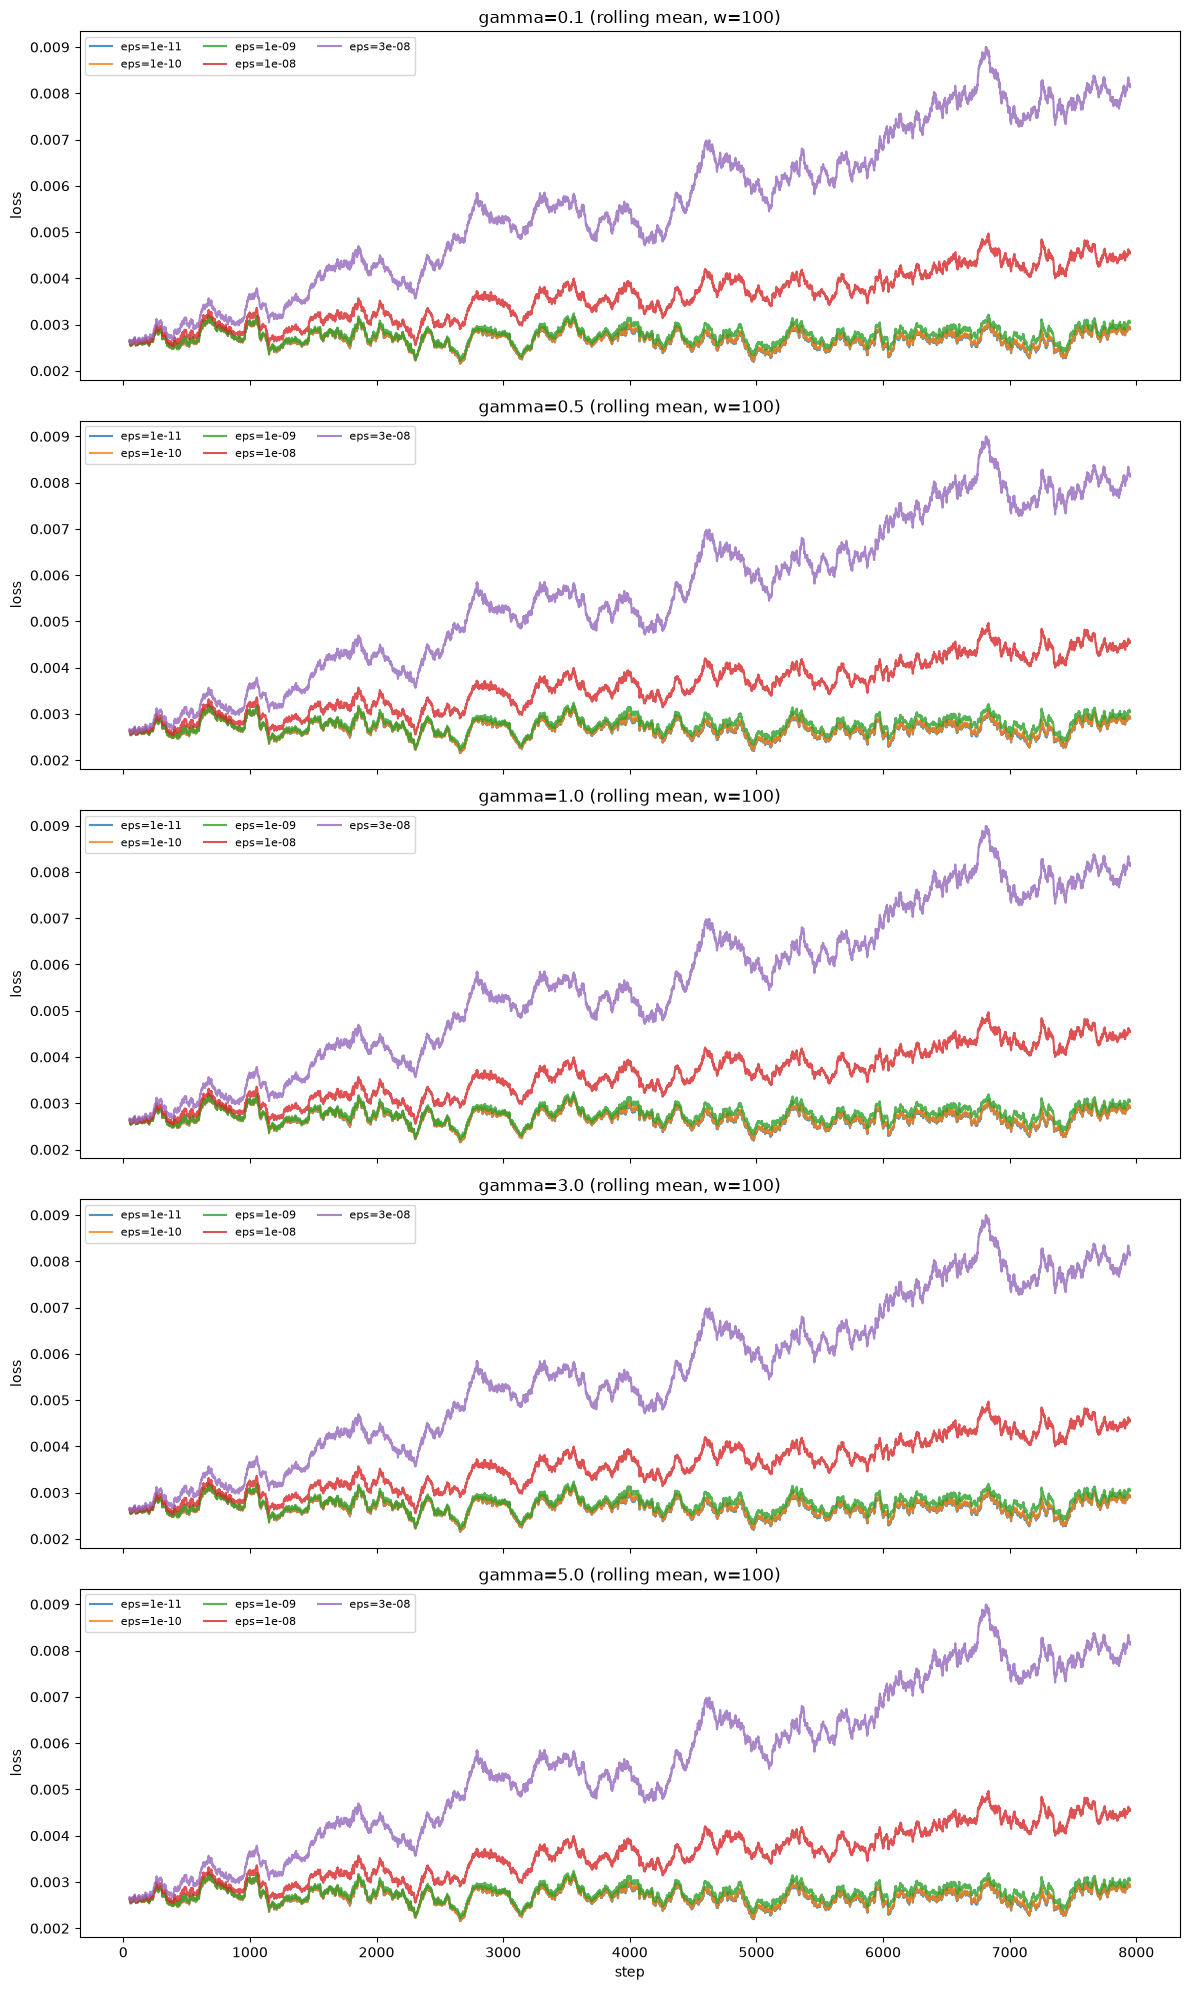

In [3]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path("/home/nakano/server/calibration_results_vision_overnight")

records = []
for subdir in ROOT.iterdir():
    f = subdir / "calib_convnext-atto.json"
    if f.exists():
        d = json.load(open(f))
        records.extend(d["records"])

# gamma, epsilon でアクセスできる辞書に整理
by_key = {(r["gamma"], r["epsilon"]): r for r in records}
gammas = sorted(set(r["gamma"] for r in records))
epsilons = sorted(set(r["epsilon"] for r in records))

print("gammas:", gammas)
print("epsilons:", epsilons)

def rolling_mean(x, window=100):
    x = np.array(x)
    return np.convolve(x, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(len(gammas), 1, figsize=(12, 4*len(gammas)), sharex=True)

for i, gamma in enumerate(gammas):
    ax = axes[i]
    for eps in epsilons:
        key = (gamma, eps)
        if key not in by_key:
            continue
        trace = np.array(by_key[key]["loss_trace"])
        rm = rolling_mean(trace, window=100)
        ax.plot(np.arange(len(rm)) + 50, rm, label=f"eps={eps:.0e}", alpha=0.8)
    ax.set_title(f"gamma={gamma} (rolling mean, w=100)")
    ax.set_ylabel("loss")
    ax.legend(fontsize=8, ncol=3)

axes[-1].set_xlabel("step")
plt.tight_layout()
plt.show()

In [4]:

import json
import numpy as np
from pathlib import Path

ROOT = Path("/home/nakano/server/calibration_results_vision_overnight")
records = []
for subdir in ROOT.iterdir():
    f = subdir / "calib_convnext-atto.json"
    if f.exists():
        records.extend(json.load(open(f))["records"])

by_key = {(r["gamma"], r["epsilon"]): r for r in records}

trace_g01 = np.array(by_key[(0.1, 1e-9)]["loss_trace"])
trace_g50 = np.array(by_key[(5.0, 1e-9)]["loss_trace"])

diff = trace_g01 - trace_g50
print("max abs diff:", np.abs(diff).max())
print("are they exactly equal?:", np.array_equal(trace_g01, trace_g50))

max abs diff: 0.00043173390440642834
are they exactly equal?: False


収録されているstep: [47921]
step=47921: accept_full_avg=0.515  nbeta=4621.2  gamma=1.0  epsilon=2.0e-07


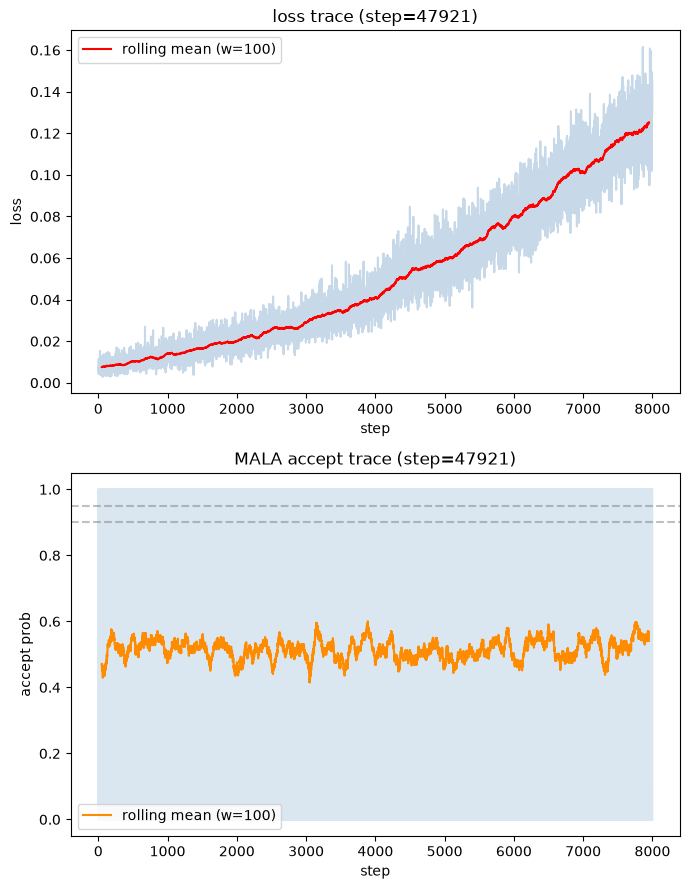


=== step=47921 (nbeta=4621.2, epsilon=2.0e-07, gamma=1.0) ===
  burnin=30% (step= 2400): llc=  277.949  avg_loss=0.06736  n_post=5600
  burnin=50% (step= 4000): llc=  343.732  avg_loss=0.08160  n_post=4000
  burnin=70% (step= 5600): llc=  421.336  avg_loss=0.09839  n_post=2400
  burnin=80% (step= 6400): llc=  464.890  avg_loss=0.10782  n_post=1600
  burnin=90% (step= 7200): llc=  509.156  avg_loss=0.11739  n_post=800


In [3]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path("/home/nakano/server/calibration_results_vision_resnet_setting")
NET = "convnext-atto"

records = {}
for f in ROOT.glob(f"calib_{NET}_step*.json"):
    d = json.load(open(f))
    for r in d["records"]:
        records[r["step"]] = r  # 同一stepが複数あればgamma/epsilonごとに要調整、今回は1パターンずつの想定

print("収録されているstep:", sorted(records.keys()))
for step, r in sorted(records.items()):
    print(f"step={step}: accept_full_avg={r['mean_accept_prob_full']:.3f}  nbeta={r['nbeta']:.1f}  "
          f"gamma={r['gamma']}  epsilon={r['epsilon']:.1e}")
    

def rolling_mean(x, window=100):
    x = np.array(x)
    return np.convolve(x, np.ones(window)/window, mode='valid')

steps_sorted = sorted(records.keys())
n = len(steps_sorted)

fig, axes = plt.subplots(2, n, figsize=(7*n, 9))
if n == 1:
    axes = axes.reshape(2, 1)

for i, step in enumerate(steps_sorted):
    r = records[step]
    trace = np.array(r["loss_trace"])
    rm = rolling_mean(trace, window=100)
    accept_trace = np.array(r["mala_accept_trace"])
    accept_rm = rolling_mean(accept_trace, window=100)

    axes[0, i].plot(trace, alpha=0.3, color="steelblue")
    axes[0, i].plot(np.arange(len(rm)) + 50, rm, color="red", label="rolling mean (w=100)")
    axes[0, i].set_title(f"loss trace (step={step})")
    axes[0, i].set_xlabel("step")
    axes[0, i].set_ylabel("loss")
    axes[0, i].legend()

    axes[1, i].plot(accept_trace, alpha=0.2, color="steelblue")
    axes[1, i].plot(np.arange(len(accept_rm)) + 50, accept_rm, color="darkorange", label="rolling mean (w=100)")
    axes[1, i].set_title(f"MALA accept trace (step={step})")
    axes[1, i].set_xlabel("step")
    axes[1, i].set_ylabel("accept prob")
    axes[1, i].set_ylim(-0.05, 1.05)
    axes[1, i].axhline(0.9, color="gray", linestyle="--", alpha=0.5)
    axes[1, i].axhline(0.95, color="gray", linestyle="--", alpha=0.5)
    axes[1, i].legend()

plt.tight_layout()
plt.show()


def compute_llc_with_burnin_step(loss_trace, nbeta, burnin_step):
    trace = np.array(loss_trace)
    post_burnin = trace[burnin_step:]
    init_loss = trace[0]
    avg_loss = post_burnin.mean()
    llc = nbeta * (avg_loss - init_loss)
    return llc, avg_loss, len(post_burnin)

for step in steps_sorted:
    r = records[step]
    print(f"\n=== step={step} (nbeta={r['nbeta']:.1f}, epsilon={r['epsilon']:.1e}, gamma={r['gamma']}) ===")
    total = len(r["loss_trace"])
    for frac in [0.3, 0.5, 0.7, 0.8, 0.9]:
        b = int(total * frac)
        llc, avg_loss, np_ = compute_llc_with_burnin_step(r["loss_trace"], r["nbeta"], b)
        print(f"  burnin={frac*100:.0f}% (step={b:5d}): llc={llc:9.3f}  avg_loss={avg_loss:.5f}  n_post={np_}")

In [ ]:
# Cell 1: 結果読み込み
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path("/home/nakano/server/calibration_results_vision_resnet_setting")
NET = "convnext-atto"

records = {}
for f in ROOT.glob(f"calib_{NET}_step*.json"):
    d = json.load(open(f))
    for r in d["records"]:
        records[r["step"]] = r

print("収録されているstep:", sorted(records.keys()))
for step, r in sorted(records.items()):
    print(f"step={step}: gamma={r['gamma']}, epsilon={r['epsilon']:.1e}, "
          f"nbeta={r['nbeta']:.1f}, total_steps={r['total_steps']}, "
          f"accept_full_avg={r['mean_accept_prob_full']:.3f}")
    
print("\n=== LLC ===")


# Cell 2: burn-inを指定してLLCを計算する関数
def compute_llc(loss_trace, nbeta, burnin_frac=None, burnin_step=None, init_loss=None):
    """
    burnin_frac: 0〜1で指定(例 0.5 なら先頭50%を捨てる)
    burnin_step: ステップ数で直接指定(指定時はburnin_fracより優先)
    init_loss: 基準loss。Noneならtrace[0]を使う(SGLD開始直後、ノイズ込みの1点)
    """
    trace = np.array(loss_trace)
    if burnin_step is None:
        burnin_step = int(len(trace) * burnin_frac)
    post_burnin = trace[burnin_step:]
    if init_loss is None:
        init_loss = trace[0]
    avg_loss = post_burnin.mean()
    llc = nbeta * (avg_loss - init_loss)
    return {
        "llc": llc,
        "avg_loss_post_burnin": avg_loss,
        "init_loss": init_loss,
        "burnin_step": burnin_step,
        "n_post_burnin": len(post_burnin),
    }
    
    
# Cell 3: burn-in を指定してLLCを計算(ここを書き換えて試す)
BURNIN_FRAC = 0.5   # ← ここを自由に変更(0.3, 0.5, 0.7, 0.9 など)

for step, r in sorted(records.items()):
    res = compute_llc(r["loss_trace"], r["nbeta"], burnin_frac=BURNIN_FRAC)
    print(f"step={step}: burnin={BURNIN_FRAC*100:.0f}% (step={res['burnin_step']})  "
          f"LLC={res['llc']:.3f}  avg_loss_post={res['avg_loss_post_burnin']:.5f}  "
          f"init_loss={res['init_loss']:.5f}  n_post={res['n_post_burnin']}")

収録されているstep: [47921]
step=47921: gamma=1.0, epsilon=2.0e-07, nbeta=4621.2, total_steps=8000, accept_full_avg=0.515

=== loss_traceの長さ ===
step=47921: burnin=50% (step=4000)  LLC=343.732  avg_loss_post=0.08160  init_loss=0.00722  n_post=4000


In [1]:
# Cell 1: 全キャリブレーション結果を読み込む
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

SERVER = Path("/home/nakano/server")
DIRS = [
    "calibration_results_vision",
    "calibration_results_vision_debugtest",
    "calibration_results_vision_gammacheck",
    "calibration_results_vision_overnight",
    "calibration_results_vision_resnet_setting",
    "calibration_results_vision_resnet_setting_short",
    "calibration_results_vision_test_gamma100",
    "calibration_results_vision_test_gpu3",
]

records = []
for d in DIRS:
    root = SERVER / d
    if not root.exists():
        continue
    # 新旧どちらの命名規則にも対応(calib_{net}.json と calib_{net}_step{step}.json)
    for f in root.rglob("calib_*.json"):
        try:
            data = json.load(open(f))
        except Exception as e:
            print(f"skip {f}: {e}")
            continue
        for r in data.get("records", []):
            r["_source_dir"] = d
            r["_source_file"] = str(f.relative_to(SERVER))
            records.append(r)

df = pd.DataFrame(records)
print(f"合計レコード数: {len(df)}")
print(df[["_source_dir", "step", "gamma", "epsilon", "total_steps",
          "mean_accept_prob_full"]].sort_values(["total_steps", "step", "gamma", "epsilon"]))

合計レコード数: 36
                                        _source_dir   step   gamma  \
3              calibration_results_vision_debugtest  62059     0.1   
1              calibration_results_vision_debugtest  62059     0.1   
2              calibration_results_vision_debugtest  62059  1000.0   
5             calibration_results_vision_gammacheck  62059     0.1   
6             calibration_results_vision_gammacheck  62059   100.0   
4             calibration_results_vision_gammacheck  62059  1000.0   
34  calibration_results_vision_resnet_setting_short  62059     1.0   
32        calibration_results_vision_resnet_setting  47921     1.0   
7              calibration_results_vision_overnight  62059     0.1   
8              calibration_results_vision_overnight  62059     0.1   
9              calibration_results_vision_overnight  62059     0.1   
22             calibration_results_vision_overnight  62059     0.1   
23             calibration_results_vision_overnight  62059     0.1   
10      